<a href="https://colab.research.google.com/github/Retr0Sys/Challenge-Prediccion-de-Veracidad-de-Declaraciones-con-IA/blob/main/Challenge_Predicci%C3%B3n_de_Veracidad_de_Declaraciones_con_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importamos pandas

In [1182]:
import pandas as pd
df = pd.read_csv("df_train.csv")

## Mostramos los primeros 5 datos

In [1183]:
df.head(5)

,ID,Etiqueta,Declaracion,Tema,Orador,Cargo del Orador,Estado,Afiliación Politica,Cantidad Verdadera,Cantidad Falsa,Contexto
0,11173,True,The Fourth Amendment was what we fought the Re...,"history,legal-issues,privacy",rand-paul,Candidate for U.S. Senate and physician,Kentucky,republican,12,18,a Republican presidential debate in Cleveland
1,1687,False,"When the United States ""first created the fede...","history,taxes",newt-gingrich,"Co-host on CNN's ""Crossfire""",Georgia,republican,10,42,a speech to the Southern Republican Leadership...
2,3322,False,Wisconsin Gov. Scott Walkers estimate of a $3....,"labor,state-budget",mark-pocan,"State Assembly member, 78th District",Wisconsin,democrat,3,3,a blog posting
3,8225,False,A proposed San Antonio ordinance will allow me...,"city-government,legal-issues",texas-values,NaN,NaN,none,0,2,an email blast
4,2516,False,Says Wisconsin Attorney General J.B. Van Holle...,"crime,legal-issues",scott-hassett,Candidate for state Attorney General,Wisconsin,democrat,0,1,an email to supporters


## Mostramos la cantidad de filas y columnas

In [1184]:
df.shape

(3127, 11)

In [1185]:
df['Afiliación Politica'].value_counts()

,count
Afiliación Politica,
republican,1367
democrat,989
none,562
organization,70
independent,44
newsmaker,18
journalist,15
libertarian,15
columnist,12


In [1186]:
df['Estado'].value_counts()

,count
Estado,
Florida,299
Texas,293
Wisconsin,249
New York,200
Illinois,158
Ohio,141
Virginia,137
Georgia,117
Rhode Island,116


In [1187]:
df['Orador'].value_counts()

,count
Orador,
barack-obama,141
hillary-clinton,78
donald-trump,75
mitt-romney,57
scott-walker,50
...,...
david-brooks,1
lynn-derbyshire,1
laura-tyson,1


In [1188]:
df['Tema'].value_counts()

,count
Tema,
health-care,124
education,85
immigration,81
taxes,78
elections,77
...,...
"county-budget,health-care",1
"energy,environment,transportation",1
"city-budget,transportation",1


## Cambiamos datos para poder utilizarlos

In [1189]:
df['Afiliación Politica'] = df ['Afiliación Politica'].map ({'republican': 1, 'democrat': 2, 'none' : 3, 'organization' : 4, 'independent' : 5, 'newsmaker' : 6, 'journalist' : 7, 'libertarian' : 8, 'columnist' : 9, 'activist' : 10, 'state-official' : 0, 'talk-show-host' : 0, 'labor-leader' : 0, 'business-leader' : 0, 'education-official' : 0, 'liberal-party-canada' : 0, 'green' : 0, 'tea-party-member ' : 0}).fillna(0)
df['Tema'] = df['Tema'].map ({'immigration' : 1,'health-care' : 2, 'candidates-biography' : 3, 'energy' : 4, 'taxes' : 5}).fillna(0)

df['Estado'] = df['Estado'].map({
    'Florida': 1,
    'Texas': 2,
    'Wisconsin': 3,
    'New York': 4,
    'Illinois': 5,
    'Ohio': 6,
    'Virginia': 7,
    'Georgia': 8,
    'Rhode Island': 9,
    'New Jersey': 10,
    'Massachusetts': 11,
    'Oregon': 12,
    'Arizona': 13,
    'California': 14,
    'Washington, D.C.': 15,
    'Pennsylvania': 16,
    'Arkansas': 17,
    'Vermont': 18,
    'New Hampshire': 19,
    'Kentucky': 20,
    'Maryland': 21,
    'Alaska': 22,
    'Tennessee': 23,
    'Delaware': 24,
    'Nevada': 25,
    'North Carolina': 26,
    'Minnesota': 27,
    'New Mexico': 28,
    'Indiana': 29,
    'South Carolina': 30,
    'Missouri': 0,
    'Louisiana': 0,
    'Michigan': 0,
    'Colorado': 0,
    'Connecticut': 0,
    'Kansas': 0,
    'Utah': 0,
    'Iowa': 0,
    'District of Columbia': 0,
    'Alabama': 0,
    'Virgina': 0,
    'Washington': 0,
    'Oklahoma': 0,
    'Maine': 0,
    'Russia': 0,
    'West Virginia': 0,
    'Washington D.C.': 0,
    'Wyoming': 0,
    'the United States': 0,
    'Idaho': 0,
    'Montana': 0,
    'Atlanta': 0,
    'South Dakota': 0,
    'Rhode island': 0,
    'Tex': 0
}).fillna(0)

df['Orador'] = df['Orador'].map({'barack-obama' : 1,'hillary-clinton' : 2,'donald-trump' : 3,'mitt-romney' : 4,'scott-walker' : 5,'david-brooks' : 0,'lynn-derbyshire' : 0,'laura-tyson' : 0,'martha-raddatz' : 0,'loren-collins' : 0}).fillna(0)
display(df.head())

,ID,Etiqueta,Declaracion,Tema,Orador,Cargo del Orador,Estado,Afiliación Politica,Cantidad Verdadera,Cantidad Falsa,Contexto
0,11173,True,The Fourth Amendment was what we fought the Re...,0.0,0.0,Candidate for U.S. Senate and physician,20.0,1.0,12,18,a Republican presidential debate in Cleveland
1,1687,False,"When the United States ""first created the fede...",0.0,0.0,"Co-host on CNN's ""Crossfire""",8.0,1.0,10,42,a speech to the Southern Republican Leadership...
2,3322,False,Wisconsin Gov. Scott Walkers estimate of a $3....,0.0,0.0,"State Assembly member, 78th District",3.0,2.0,3,3,a blog posting
3,8225,False,A proposed San Antonio ordinance will allow me...,0.0,0.0,NaN,0.0,3.0,0,2,an email blast
4,2516,False,Says Wisconsin Attorney General J.B. Van Holle...,0.0,0.0,Candidate for state Attorney General,3.0,2.0,0,1,an email to supporters


## Mostramos lo que contiene el DF

In [1190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3127 entries, 0 to 3126
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   3127 non-null   int64  
 1   Etiqueta             3127 non-null   bool   
 2   Declaracion          3127 non-null   object 
 3   Tema                 3127 non-null   float64
 4   Orador               3127 non-null   float64
 5   Cargo del Orador     2208 non-null   object 
 6   Estado               3127 non-null   float64
 7   Afiliación Politica  3127 non-null   float64
 8   Cantidad Verdadera   3127 non-null   int64  
 9   Cantidad Falsa       3127 non-null   int64  
 10  Contexto             3093 non-null   object 
dtypes: bool(1), float64(4), int64(3), object(3)
memory usage: 247.5+ KB


## Mostramos la cantidad de datos vacios por columna

In [1191]:
df.isnull().sum()

,0
ID,0
Etiqueta,0
Declaracion,0
Tema,0
Orador,0
Cargo del Orador,919
Estado,0
Afiliación Politica,0
Cantidad Verdadera,0
Cantidad Falsa,0


## **Quitamos columnas irrelevantes**

In [1192]:
df.drop(columns='Cargo del Orador', inplace=True)
df.drop(columns='Contexto', inplace=True)
df.isnull().sum()

,0
ID,0
Etiqueta,0
Declaracion,0
Tema,0
Orador,0
Estado,0
Afiliación Politica,0
Cantidad Verdadera,0
Cantidad Falsa,0


## Verificamos duplicados

In [1193]:
print("Cantidad de filas antes de eliminar duplicado", df.shape)
df.drop_duplicates(inplace=True)
print("Cantidad de filas después de eliminar duplicado", df.shape)

Cantidad de filas antes de eliminar duplicado (3127, 9)
Cantidad de filas después de eliminar duplicado (3127, 9)


## **Mapa de calor para comprobar variables relevantes**

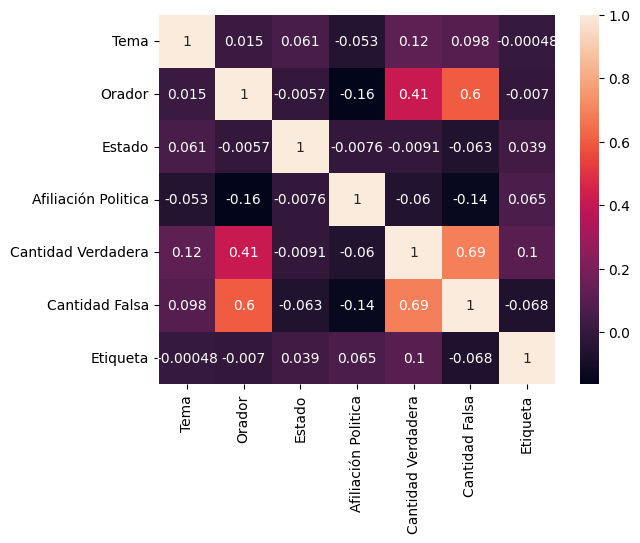

In [1194]:
import seaborn as sns
import matplotlib.pyplot as plt


cols = ['Tema','Orador','Estado','Afiliación Politica','Cantidad Verdadera','Cantidad Falsa','Etiqueta']


sns.heatmap(df[cols].corr(), annot=True)
plt.show()

## Preparamos el modelo (KNeighborsClassifier)

In [1195]:
caracteristicas = ['Cantidad Verdadera','Afiliación Politica','Estado']

X = df[caracteristicas]

y = df['Etiqueta']

In [1196]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [1197]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [1198]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=5)

modelo.fit(X_train, y_train)

predit = modelo.predict(X_val)

accuracy = accuracy_score(y_val, predit)

print('Exactitud en el conjunto de validación:', accuracy)

Exactitud en el conjunto de validación: 0.5575079872204473


## **Montamos el archivo de prueba**

In [1199]:
df_test = pd.read_csv("df_test_sin_etiqueta.csv")
display(df_test.head())

,ID,Declaracion,Tema,Orador,Cargo del Orador,Estado,Afiliación Politica,Cantidad Verdadera,Cantidad Falsa,Contexto
0,12130,Says her representation of an ex-boyfriend who...,"candidates-biography,children,ethics,families,...",rebecca-bradley,NaN,NaN,none,1,1,a radio interview
1,6418,Says he never voted for a tax increase.,"debt,deficit,taxes",mark-neumann,Developer and homebuilder,Wisconsin,republican,2,7,campaign website statements
2,191,"""Gov. Romney's own health care plan in Massach...",abortion,fred-thompson,Actor,Tennessee,republican,3,5,an email press release
3,13373,Says drug dealers have overdosed on purpose to...,"crime,drugs,legal-issues",chris-sununu,Executive Councilor,New Hampshire,republican,0,2,a No Labels forum
4,8078,Says the reasoning behind Portlands high water...,"city-government,government-efficiency,water",portlanders-water-reform,NaN,Oregon,none,0,1,a fundraising letter.


In [1200]:
df_test['Afiliación Politica'] = df_test ['Afiliación Politica'].map ({'republican': 1, 'democrat': 2, 'none' : 3, 'organization' : 4, 'independent' : 5, 'newsmaker' : 6, 'journalist' : 7, 'libertarian' : 8, 'columnist' : 9, 'activist' : 10, 'state-official' : 0, 'talk-show-host' : 0, 'labor-leader' : 0, 'business-leader' : 0, 'education-official' : 0, 'liberal-party-canada' : 0, 'green' : 0, 'tea-party-member ' : 0}).fillna(0)
df_test['Tema'] = df_test['Tema'].map ({'immigration' : 1,'health-care' : 2, 'candidates-biography' : 3, 'energy' : 4, 'taxes' : 5}).fillna(0)
df_test['Estado'] = df_test['Estado'].map({
    'Florida': 1,
    'Texas': 2,
    'Wisconsin': 3,
    'New York': 4,
    'Illinois': 5,
    'Ohio': 6,
    'Virginia': 7,
    'Georgia': 8,
    'Rhode Island': 9,
    'New Jersey': 10,
    'Massachusetts': 11,
    'Oregon': 12,
    'Arizona': 13,
    'California': 14,
    'Washington, D.C.': 15,
    'Pennsylvania': 16,
    'Arkansas': 17,
    'Vermont': 18,
    'New Hampshire': 19,
    'Kentucky': 20,
    'Maryland': 21,
    'Alaska': 22,
    'Tennessee': 23,
    'Delaware': 24,
    'Nevada': 25,
    'North Carolina': 26,
    'Minnesota': 27,
    'New Mexico': 28,
    'Indiana': 29,
    'South Carolina': 30,
    'Missouri': 0,
    'Louisiana': 0,
    'Michigan': 0,
    'Colorado': 0,
    'Connecticut': 0,
    'Kansas': 0,
    'Utah': 0,
    'Iowa': 0,
    'District of Columbia': 0,
    'Alabama': 0,
    'Virgina': 0,
    'Washington': 0,
    'Oklahoma': 0,
    'Maine': 0,
    'Russia': 0,
    'West Virginia': 0,
    'Washington D.C.': 0,
    'Wyoming': 0,
    'the United States': 0,
    'Idaho': 0,
    'Montana': 0,
    'Atlanta': 0,
    'South Dakota': 0,
    'Rhode island': 0,
    'Tex': 0
}).fillna(0)
df_test['Orador'] = df_test['Orador'].map({'barack-obama' : 1,'hillary-clinton' : 2,'donald-trump' : 3,'mitt-romney' : 4,'scott-walker' : 5,'david-brooks' : 0,'lynn-derbyshire' : 0,'laura-tyson' : 0,'martha-raddatz' : 0,'loren-collins' : 0}).fillna(0)
df_test.drop(columns='Cargo del Orador', inplace=True)
df_test.drop(columns='Contexto', inplace=True)
caracteristicas = ['Cantidad Verdadera','Afiliación Politica','Estado']
X_test = df_test[caracteristicas]
display(X_test.head())

,Cantidad Verdadera,Afiliación Politica,Estado
0,1,3.0,0.0
1,2,1.0,3.0
2,3,1.0,23.0
3,0,1.0,19.0
4,0,3.0,12.0


In [1201]:
X_test = scaler.transform(X_test)

In [1202]:
predictions = modelo.predict(X_test)

## **Creamos el archivo de salida**

In [1203]:
submission_df = pd.DataFrame({'ID': df_test['ID'], 'Etiqueta': predictions})
submission_df.to_csv('submission.csv', index=False)